<a href="https://colab.research.google.com/github/EvertonSantos3/Chalenge-TeleconX/blob/main/TelecomX_BR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracão

In [21]:
import pandas as pd
import requests

In [22]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"

response = requests.get(url)

data = response.json()

In [23]:
df = pd.DataFrame(data)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [24]:
df.shape

(7267, 6)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [26]:
df.head(10)

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
5,0013-MHZWF,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
6,0013-SMEOE,No,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Two year', 'PaperlessBilling': '..."
7,0014-BMAQU,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Two year', 'PaperlessBilling': '..."
8,0015-UOCOJ,No,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
9,0016-QLJIS,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


#🔧 Transformação

In [27]:
customer_df = pd.json_normalize(df['customer'])

In [28]:
phone_df = pd.json_normalize(df['phone'])

In [29]:
internet_df = pd.json_normalize(df['internet'])

In [30]:
account_df = pd.json_normalize(df['account'])

In [31]:
df_final = pd.concat(
    [df[['customerID', 'Churn']],
     customer_df,
     phone_df,
     internet_df,
     account_df],
    axis=1
)

In [32]:
df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [33]:
df_final.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [34]:
df_final.duplicated().sum()

np.int64(0)

In [35]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [36]:
df_final["Contract"].unique()
df_final["PaymentMethod"].unique()
df_final["PhoneService"].unique()
df_final["MultipleLines"].unique()

array(['No', 'Yes', 'No phone service'], dtype=object)

In [37]:
df_final["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


In [38]:
df_final.describe()

,SeniorCitizen,tenure,Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


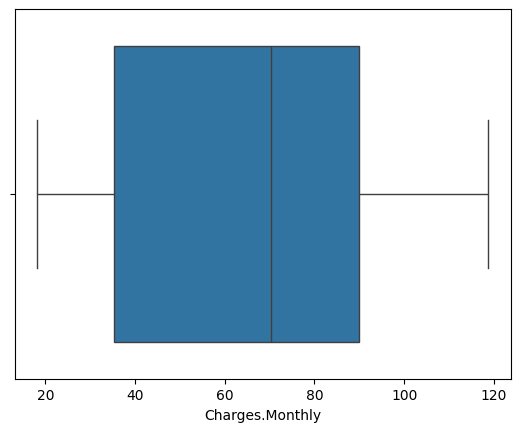

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df_final["Charges.Monthly"])
plt.show()

In [42]:
df_final["Charges.Total"] = df_final["Charges.Total"].replace(" ", 0).astype(float)

In [43]:
df_final["Contas_Diarias"] = (df_final["Charges.Monthly"] / 30).round(2)

In [44]:
df_final[["Charges.Monthly", "Contas_Diarias"]].head()

,Charges.Monthly,Contas_Diarias
0,65.6,2.19
1,59.9,2.00
2,73.9,2.46
3,98.0,3.27
4,83.9,2.80


In [45]:
df_final["Churn"] = df_final["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [46]:
yes_no_cols = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

for col in yes_no_cols:
    df_final[col] = df_final[col].map({"Yes":1, "No":0})

In [47]:
df_final["gender"] = df_final["gender"].map({
    "Female":0,
    "Male":1
})

In [48]:
df_final = df_final.rename(columns={
    "tenure": "Tempo_Cliente",
    "Charges.Monthly": "Cobranca_Mensal",
    "Charges.Total": "Cobranca_Total",
    "InternetService": "Servico_Internet",
    "PaymentMethod": "Metodo_Pagamento"
})

In [49]:
df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,Tempo_Cliente,PhoneService,MultipleLines,Servico_Internet,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,Metodo_Pagamento,Cobranca_Mensal,Cobranca_Total,Contas_Diarias
0,0002-ORFBO,0.0,0,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0.0,1,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1.0,1,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1.0,1,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1.0,0,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [50]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7043 non-null   float64
 2   gender            7267 non-null   int64  
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   int64  
 5   Dependents        7267 non-null   int64  
 6   Tempo_Cliente     7267 non-null   int64  
 7   PhoneService      7267 non-null   int64  
 8   MultipleLines     7267 non-null   object 
 9   Servico_Internet  7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


#📊 Carga e análise

In [51]:
df_final.describe()

,Churn,gender,SeniorCitizen,Partner,Dependents,Tempo_Cliente,PhoneService,PaperlessBilling,Cobranca_Mensal,Cobranca_Total,Contas_Diarias
count,7043.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.265370,0.505711,0.162653,0.484106,0.300124,32.346498,0.902711,0.593230,64.720098,2277.182035,2.157292
std,0.441561,0.500002,0.369074,0.499782,0.458343,24.571773,0.296371,0.491265,30.129572,2268.648587,1.004407
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.425000,396.200000,1.180000
50%,0.000000,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1389.200000,2.340000
75%,1.000000,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.875000,3778.525000,2.995000
max,1.000000,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


In [54]:
df_final["Tempo_Cliente"].describe()

,Tempo_Cliente
count,7267.000000
mean,32.346498
std,24.571773
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


In [56]:
df_final["Cobranca_Mensal"].describe()

,Cobranca_Mensal
count,7267.000000
mean,64.720098
std,30.129572
min,18.250000
25%,35.425000
50%,70.300000
75%,89.875000
max,118.750000


In [58]:
df_final["Cobranca_Mensal"].mean()

np.float64(64.72009770194028)

In [59]:
df_final["Cobranca_Mensal"].median()

70.3

In [60]:
df_final["Cobranca_Mensal"].std()

30.12957188566699

In [61]:
df_final["Contract"].value_counts()

,count
Contract,
Month-to-month,4005
Two year,1743
One year,1519


In [62]:
df_final["Contract"].value_counts(normalize=True) * 100

,proportion
Contract,
Month-to-month,55.112151
Two year,23.985138
One year,20.902711


In [64]:
df_final.groupby("Churn")[["Tempo_Cliente","Cobranca_Mensal","Cobranca_Total"]].mean()

,Tempo_Cliente,Cobranca_Mensal,Cobranca_Total
Churn,,,
0.0,37.569965,61.265124,2549.911442
1.0,17.979133,74.441332,1531.796094


In [65]:
df_final["Churn"].value_counts()

,count
Churn,
0.0,5174
1.0,1869


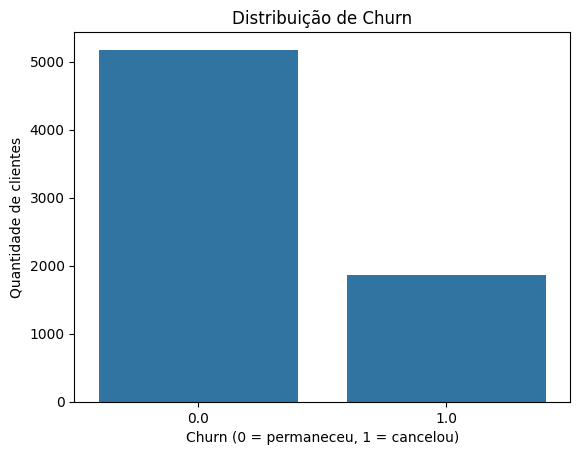

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df_final)

plt.title("Distribuição de Churn")
plt.xlabel("Churn (0 = permaneceu, 1 = cancelou)")
plt.ylabel("Quantidade de clientes")

plt.show()

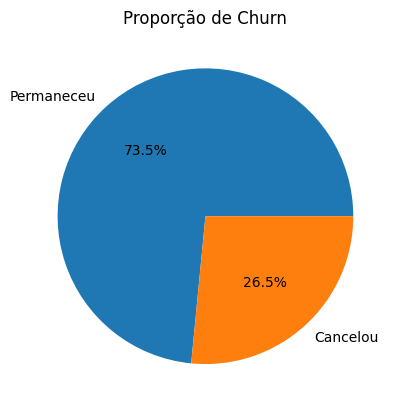

In [67]:
df_final["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Permaneceu","Cancelou"]
)

plt.title("Proporção de Churn")
plt.ylabel("")

plt.show()

In [68]:
df_final["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
0.0,73.463013
1.0,26.536987


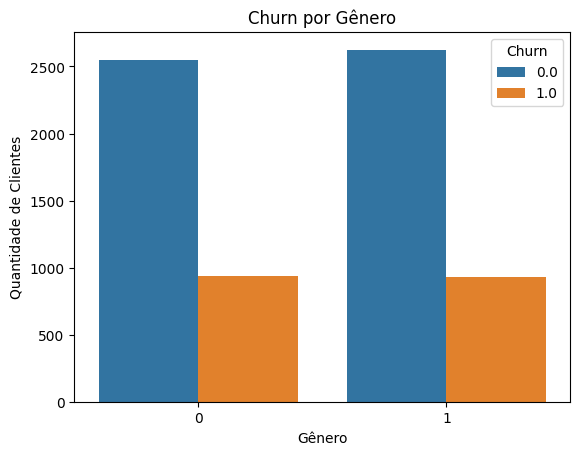

In [69]:
sns.countplot(x="gender", hue="Churn", data=df_final)

plt.title("Churn por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Quantidade de Clientes")

plt.show()

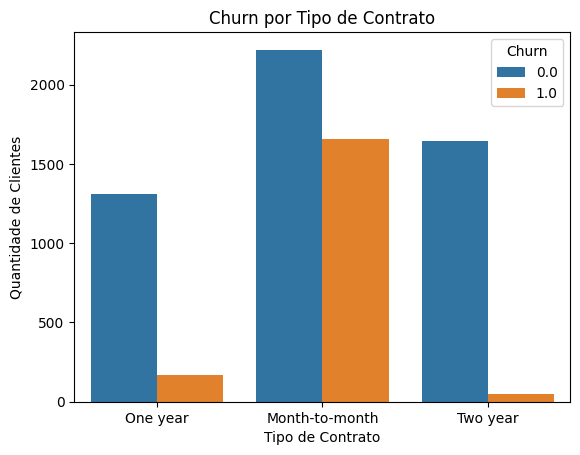

In [70]:
sns.countplot(x="Contract", hue="Churn", data=df_final)

plt.title("Churn por Tipo de Contrato")
plt.xlabel("Tipo de Contrato")
plt.ylabel("Quantidade de Clientes")

plt.show()

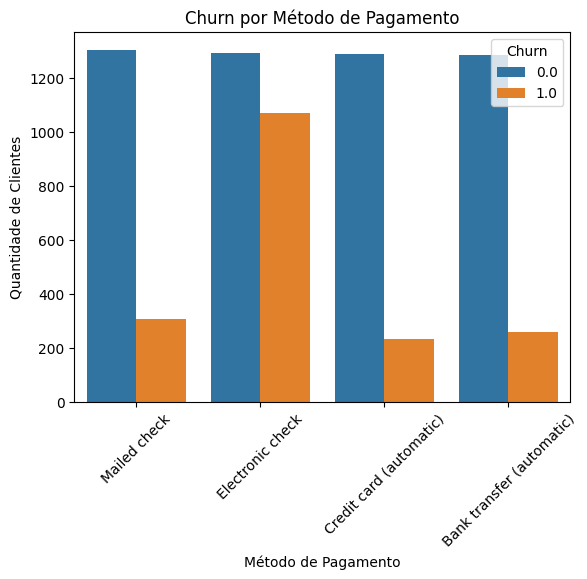

In [72]:
sns.countplot(x="Metodo_Pagamento", hue="Churn", data=df_final)

plt.title("Churn por Método de Pagamento")
plt.xlabel("Método de Pagamento")
plt.ylabel("Quantidade de Clientes")

plt.xticks(rotation=45)

plt.show()

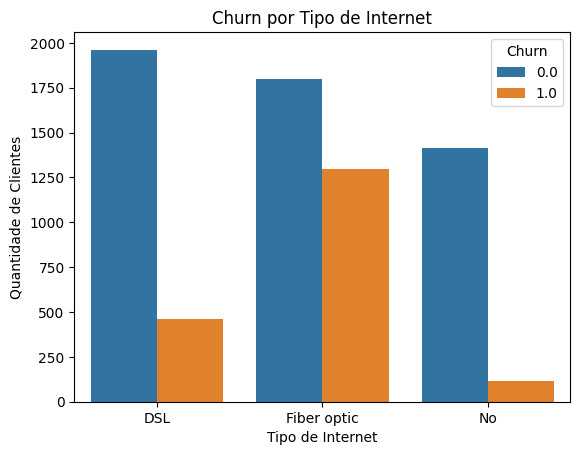

In [74]:
sns.countplot(x="Servico_Internet", hue="Churn", data=df_final)

plt.title("Churn por Tipo de Internet")
plt.xlabel("Tipo de Internet")
plt.ylabel("Quantidade de Clientes")

plt.show()

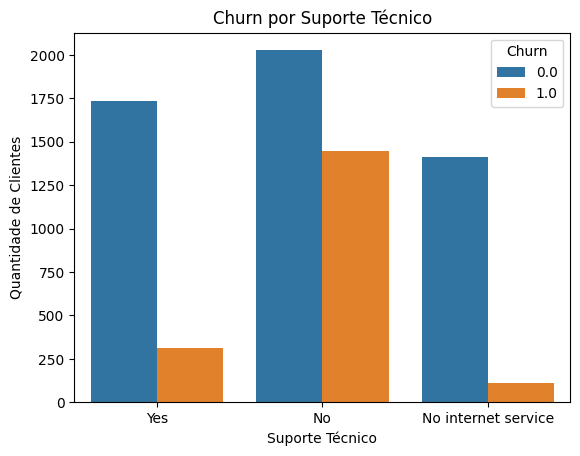

In [75]:
sns.countplot(x="TechSupport", hue="Churn", data=df_final)

plt.title("Churn por Suporte Técnico")
plt.xlabel("Suporte Técnico")
plt.ylabel("Quantidade de Clientes")

plt.show()

In [76]:
pd.crosstab(df_final["Contract"], df_final["Churn"], normalize="index") * 100

Churn,0.0,1.0
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [78]:
df_final.groupby("Churn")[["Tempo_Cliente","Cobranca_Mensal","Cobranca_Total","Contas_Diarias"]].mean()

,Tempo_Cliente,Cobranca_Mensal,Cobranca_Total,Contas_Diarias
Churn,,,,
0.0,37.569965,61.265124,2549.911442,2.04208
1.0,17.979133,74.441332,1531.796094,2.48145


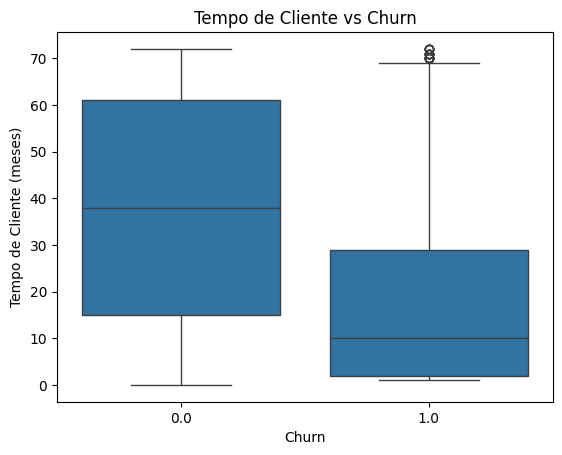

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="Churn", y="Tempo_Cliente", data=df_final)

plt.title("Tempo de Cliente vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tempo de Cliente (meses)")

plt.show()

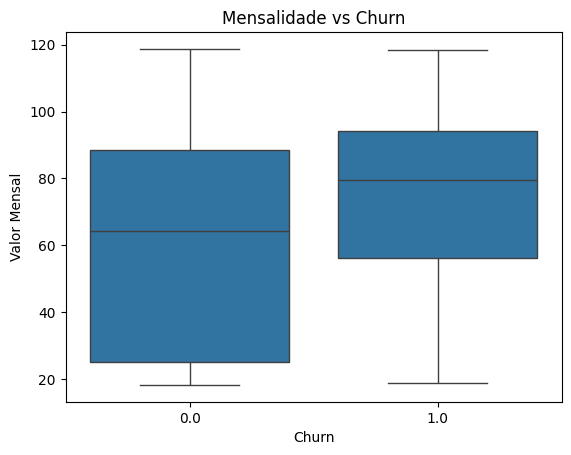

In [82]:
sns.boxplot(x="Churn", y="Cobranca_Mensal", data=df_final)

plt.title("Mensalidade vs Churn")
plt.xlabel("Churn")
plt.ylabel("Valor Mensal")

plt.show()

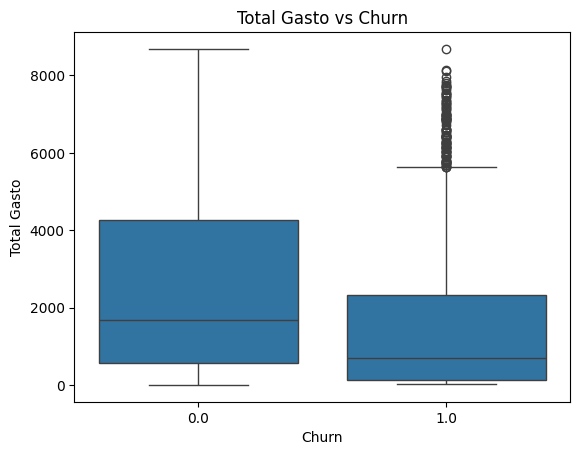

In [84]:
sns.boxplot(x="Churn", y="Cobranca_Total", data=df_final)

plt.title("Total Gasto vs Churn")
plt.xlabel("Churn")
plt.ylabel("Total Gasto")

plt.show()

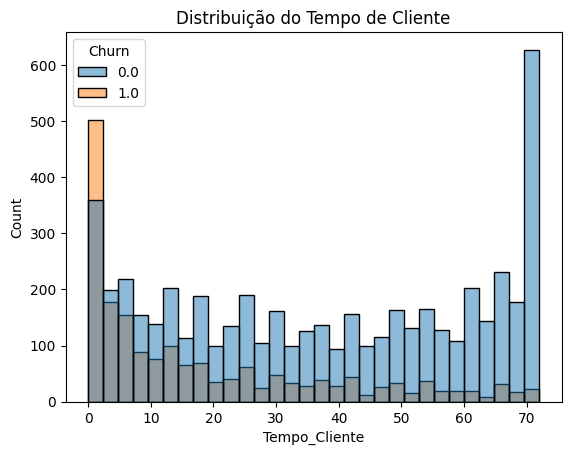

In [86]:
sns.histplot(data=df_final, x="Tempo_Cliente", hue="Churn", bins=30)

plt.title("Distribuição do Tempo de Cliente")

plt.show()

#📄Relatorio Final

📊 Relatório de Análise de Evasão de Clientes – Telecom X
1. Introdução

A evasão de clientes, conhecida como Churn, é um dos principais desafios enfrentados por empresas de telecomunicações. Quando um cliente cancela um serviço, a empresa perde receita e precisa investir mais recursos para adquirir novos clientes.

O objetivo desta análise é investigar os fatores associados ao cancelamento de clientes na Telecom X, utilizando técnicas de análise de dados para identificar padrões e comportamentos que possam explicar a evasão.

A partir dessa análise, será possível gerar insights estratégicos que poderão auxiliar a empresa na criação de ações para reduzir o churn e melhorar a retenção de clientes.

🧹 2. Limpeza e Tratamento de Dados

Inicialmente, os dados foram obtidos por meio de uma API em formato JSON e importados para o ambiente Python utilizando a biblioteca Pandas.

Durante o processo de preparação dos dados foram realizadas as seguintes etapas:

Importação dos dados da API e conversão para DataFrame.

Normalização das colunas que continham estruturas JSON aninhadas, como:

customer

phone

internet

account

Verificação de valores ausentes, onde foi identificado que a base não possuía dados nulos.

Verificação de registros duplicados, não sendo encontrados duplicados na base.

Ajuste de tipos de dados, como a conversão da variável Charges.Total para formato numérico.

Criação de uma nova variável chamada Contas_Diarias, calculada a partir da cobrança mensal dividida por 30 dias.

Padronização de algumas variáveis categóricas, convertendo valores como Yes/No para 1/0 quando necessário para facilitar análises posteriores.

Após essas etapas, os dados ficaram estruturados e adequados para a realização da análise exploratória.

📈 3. Análise Exploratória de Dados

A análise exploratória teve como objetivo entender a distribuição dos dados e identificar padrões relacionados ao churn.

Distribuição do Churn

Foi analisada a proporção de clientes que cancelaram o serviço em relação aos que permaneceram.

Os resultados mostraram que:

Aproximadamente 73% dos clientes permaneceram na empresa

Cerca de 27% dos clientes cancelaram o serviço

Essa taxa indica um nível relevante de evasão que merece atenção estratégica.

Análise por Variáveis Categóricas

Foram analisadas diversas variáveis categóricas para verificar sua relação com o churn, incluindo:

Gênero

Tipo de contrato

Método de pagamento

Tipo de serviço de internet

Suporte técnico

Os gráficos indicaram que:

Clientes com contratos mensais (Month-to-month) apresentam maior taxa de cancelamento.

Contratos de um ou dois anos apresentam menor evasão, sugerindo maior fidelização.

Clientes que utilizam pagamentos eletrônicos tendem a apresentar maior churn.

Clientes sem suporte técnico demonstram maior tendência a cancelar o serviço.

Análise por Variáveis Numéricas

Também foram analisadas variáveis numéricas como:

Tempo de cliente (tenure)

Cobrança mensal

Total gasto pelo cliente

Os resultados indicaram que:

Clientes que cancelaram possuem menor tempo médio de permanência na empresa.

Muitos cancelamentos ocorrem nos primeiros meses de contrato.

Clientes com mensalidades mais elevadas apresentam uma leve tendência a cancelar com maior frequência.

Clientes que cancelaram apresentam menor valor total gasto, indicando menor tempo de relacionamento com a empresa.

📊 4. Conclusões e Insights

A análise dos dados permitiu identificar alguns fatores importantes associados à evasão de clientes.

Os principais insights foram:

O tipo de contrato é um dos fatores mais relevantes para o churn, sendo que clientes com contratos mensais apresentam maior probabilidade de cancelamento.

O tempo de permanência na empresa está fortemente relacionado à evasão, com maior incidência de cancelamentos entre clientes mais recentes.

Alguns métodos de pagamento estão associados a maiores taxas de churn.

Clientes que utilizam menos serviços ou suporte técnico demonstram maior probabilidade de cancelar o serviço.

Esses padrões indicam que fatores relacionados ao nível de compromisso do cliente com a empresa e ao engajamento com os serviços contratados influenciam diretamente na evasão.

💡 5. Recomendações

Com base nos resultados da análise, algumas estratégias podem ser sugeridas para reduzir a evasão de clientes:

1. Incentivar contratos de longo prazo

Oferecer benefícios ou descontos para clientes que optarem por contratos anuais ou de dois anos pode ajudar a aumentar a retenção.

2. Melhorar a experiência nos primeiros meses

Como muitos cancelamentos ocorrem no início do relacionamento, é importante investir em programas de onboarding e acompanhamento inicial do cliente.

3. Oferecer serviços adicionais

Clientes que utilizam mais serviços tendem a permanecer por mais tempo. Estratégias de pacotes ou bundles de serviços podem aumentar o engajamento.

4. Monitorar clientes com alto risco de churn

Utilizar os padrões identificados para criar modelos preditivos que identifiquem clientes com maior probabilidade de cancelamento.

5. Fortalecer canais de suporte

Clientes com acesso a suporte técnico tendem a apresentar menor taxa de evasão, indicando que melhorar esse serviço pode contribuir para maior retenção.